<a href="https://colab.research.google.com/github/anshikaaggarwalmca2025-sys/Python_Project/blob/main/Financial_Fraud_analysis_Python_100k.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#Using a standard Matplotlib style
plt.style.use('ggplot')

In [8]:
#Number of Records
n_records = 100000
#Create synthetic financial dataset
data = {'Transaction_ID': range(100001,100001 + n_records),
        'Amount' : np.random.uniform(500, 200000, n_records).round(2),
        'Location' : np.random.choice(['Mumbai','Delhi','Meerut','Bangalore','Pune'], n_records),
        'Device' : np.random.choice(['Android','iPhone','Desktop','Tablet'], n_records),
        'Is_Fraud': np.random.choice([0, 1], n_records, p=[0.96, 0.04]) # 4% fraud rate
         }
#Create DataFrame
df = pd.DataFrame(data)
print("100,000 Records generated successfully.")

100,000 Records generated successfully.


In [9]:
df.head()

,Transaction_ID,Amount,Location,Device,Is_Fraud
0,100001,187576.20,Bangalore,Desktop,0
1,100002,165201.37,Delhi,iPhone,1
2,100003,124746.17,Pune,Android,0
3,100004,192279.09,Bangalore,Android,0
4,100005,74948.47,Pune,Tablet,0


In [11]:
#Check for missing values to ensure data integrity
print("Missing values per column:\n", df.isnull().sum())

#Generate statistical summary for the transaction amounts
print("\nFunctional Summary:\n",df['Amount'].describe())

Missing values per column:
 Transaction_ID    0
Amount            0
Location          0
Device            0
Is_Fraud          0
dtype: int64

Functional Summary:
 count    100000.000000
mean     100078.528369
std       57581.006973
min         501.060000
25%       50186.895000
50%       99935.405000
75%      150060.595000
max      199999.860000
Name: Amount, dtype: float64


In [12]:
# Grouping data by location to see where fraud is happening most
location_fraud = df.groupby('Location')['Is_Fraud'].sum().sort_values(ascending=False)
print("Total Fraud Cases by Location:\n", location_fraud)

# Identifying high-risk transactions (Amount > 150k and flagged as fraud)
# This shows we can filter large datasets based on specific conditions
high_value_fraud = df[(df['Amount'] > 150000) & (df['Is_Fraud'] == 1)]
print(f"\nTotal High-Value Fraud Cases Identified: {len(high_value_fraud)}")

# Seeing which device is most commonly used for fraud
device_fraud = df.groupby('Device')['Is_Fraud'].sum().sort_values(ascending=False)
print("\nFraud Cases by Device Type:\n", device_fraud)

Total Fraud Cases by Location:
 Location
Meerut       832
Pune         826
Bangalore    790
Delhi        787
Mumbai       751
Name: Is_Fraud, dtype: int64

Total High-Value Fraud Cases Identified: 976

Fraud Cases by Device Type:
 Device
Desktop    1017
Android     997
Tablet      987
iPhone      985
Name: Is_Fraud, dtype: int64


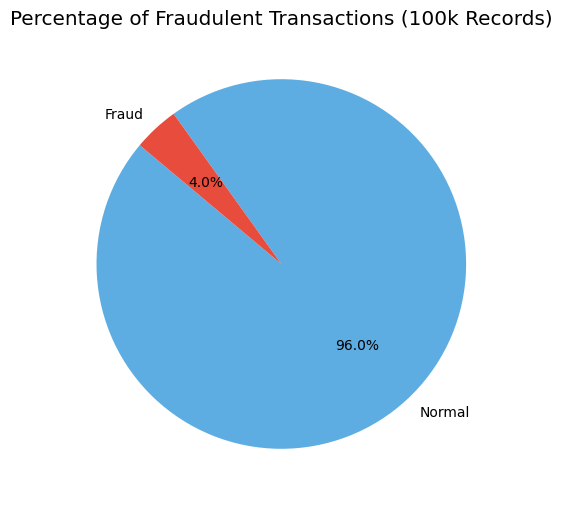

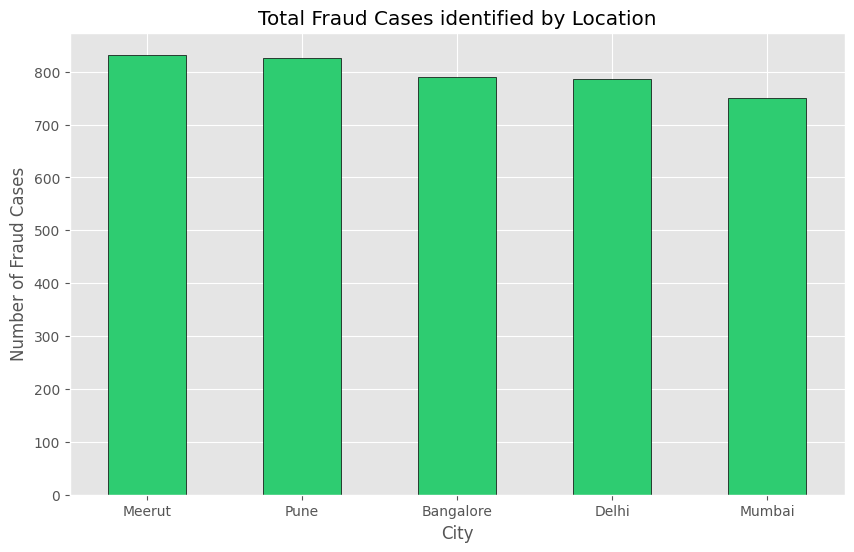

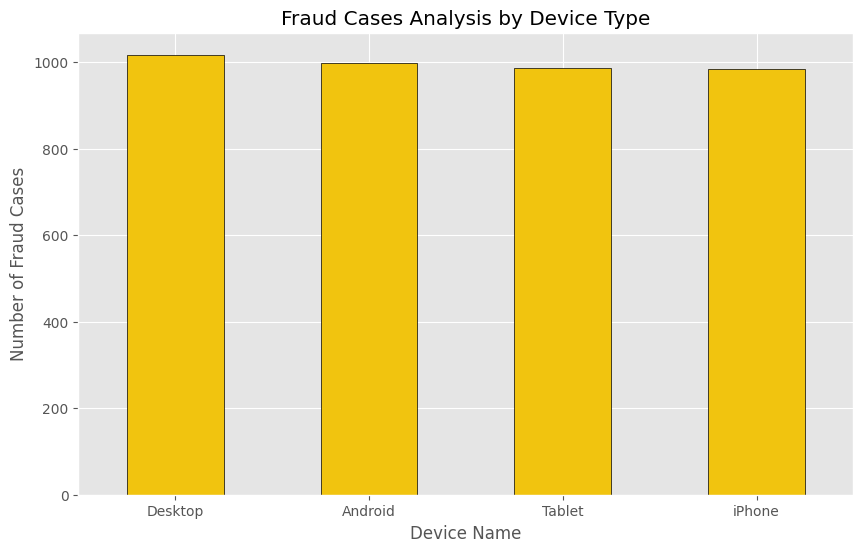

In [13]:
# Chart 1: Proportion of Fraud vs Normal Transactions
plt.figure(figsize=(8, 6))
fraud_counts = df['Is_Fraud'].value_counts()
plt.pie(fraud_counts, labels=['Normal', 'Fraud'], autopct='%1.1f%%', colors=['#5DADE2', '#E74C3C'], startangle=140)
plt.title('Percentage of Fraudulent Transactions (100k Records)')
plt.show()

# Chart 2: Fraud Cases by Location
plt.figure(figsize=(10, 6))
location_fraud.plot(kind='bar', color='#2ECC71', edgecolor='black')
plt.title('Total Fraud Cases identified by Location')
plt.xlabel('City')
plt.ylabel('Number of Fraud Cases')
plt.xticks(rotation=0) # Keep city names horizontal
plt.show()

# Chart 3: Fraud Cases by Device
plt.figure(figsize=(10, 6))
device_fraud.plot(kind='bar', color='#F1C40F', edgecolor='black')
plt.title('Fraud Cases Analysis by Device Type')
plt.xlabel('Device Name')
plt.ylabel('Number of Fraud Cases')
plt.xticks(rotation=0)
plt.show()